<a href="https://colab.research.google.com/github/osoria80/07MIAR-Redes-neuronales-y-deep-learning/blob/main/S3_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Funcioens utils previas**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
import sympy as sp
import numpy as np

# --- Definición simbólica (se hace UNA sola vez) ---
x1, x2, w1, w2, b_sym, y_sym = sp.symbols('x1 x2 w1 w2 b y')

z = x1*w1 + x2*w2 + b_sym
a_sym = 1 / (1 + sp.exp(-z))
J = (a_sym - y_sym)**2

def derivada(funcion, variable):
    return sp.diff(funcion, variable)

In [20]:
def draw_plot(train_losses, train_accuracies, val_losses, val_accuracies, test_loss, test_acc):
  epochs_range = range(1, len(train_losses) + 1)

  # Figura ancha para que las dos gráficas quepan bien juntas
  plt.figure(figsize=(12, 4))
  # Divide la figura en 1 fila y 2 columnas, activa posición 1 (izquierda) -> gráfica de Loss
  plt.subplot(1, 2, 1)
  # Ver ambas curvas juntas permite detectar overfitting (train baja pero val sube)
  plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
  plt.plot(epochs_range, val_losses,   marker="o", label="Val Loss")
  # Línea roja horizontal con el valor del test para compararlo visualmente con val
  plt.axhline(y=test_loss, color="red", linestyle="--", label=f"Test Loss: {test_loss:.4f}")
  # Etiquetas, título, leyenda y cuadrícula: sin esto la gráfica es ilegible
  plt.xlabel("Época")
  plt.ylabel("Loss")
  plt.title("Pérdida en Train y Validation")
  plt.legend()
  plt.grid(True)

  # Activa posición 2 (derecha) -> gráfica de Accuracy (misma lógica que Loss)
  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, train_accuracies, marker="o", label="Train Accuracy")
  plt.plot(epochs_range, val_accuracies,   marker="o", label="Val Accuracy")
  plt.axhline(y=test_acc, color="red", linestyle="--", label=f"Test Acc: {test_acc:.4f}")
  plt.xlabel("Época")
  plt.ylabel("Accuracy")
  plt.title("Accuracy en Train y Validation")
  plt.legend()
  plt.grid(True)

  # Ajusta márgenes automáticamente para que las gráficas no se solapen
  plt.tight_layout()
  # Renderiza y muestra todo lo dibujado (sin esto en algunos entornos no aparece nada)
  plt.show()

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0, x)

def linear(x):
  return x

def visualizar_neurona(entradas, pesos, bias, activacion=sigmoid, nombre_activacion="sigmoid"):
    entradas = np.array(entradas, dtype=float)
    pesos = np.array(pesos, dtype=float)

    contribuciones = entradas * pesos
    z = np.sum(contribuciones) + bias
    a = activacion(z)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Entradas
    axes[0].bar(range(len(entradas)), entradas)
    axes[0].set_title("Entradas")
    axes[0].set_xlabel("Entrada")
    axes[0].set_ylabel("Valor")
    axes[0].set_xticks(range(len(entradas)))
    axes[0].set_xticklabels([f"x{i+1}" for i in range(len(entradas))])
    axes[0].grid(True, axis="y")

    # Entradas * pesos + bias
    etiquetas = [f"x{i+1}·w{i+1}" for i in range(len(entradas))] + ["bias"]
    valores = list(contribuciones) + [bias]
    axes[1].bar(etiquetas, valores)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_title(f"Suma ponderada: z = {z:.3f}")
    axes[1].grid(True, axis="y")

    # Activación
    xs = np.linspace(-6, 6, 400)
    ys = activacion(xs)
    axes[2].plot(xs, ys)
    axes[2].scatter([z], [a], s=80)
    axes[2].axvline(z, linestyle="--")
    axes[2].set_title(f"Salida: {nombre_activacion}(z) = {a:.3f}")
    axes[2].set_xlabel("z")
    axes[2].set_ylabel("a")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    print("entradas =", entradas)
    print("pesos =", pesos)
    print("bias =", bias)
    print("entradas * pesos =", contribuciones)
    print("z =", z)
    print("salida =", a)

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0, x)

def linear(x):
  return x

In [ ]:
def neurona(entradas, pesos, bias, activacion=sigmoid):
    entradas = np.array(entradas, dtype=float)
    pesos = np.array(pesos, dtype=float)

    z = np.sum(entradas * pesos) + bias
    a = activacion(z)

    return a

In [ ]:
def capa(entradas, neuronas):
    salidas = []

    for i, n in enumerate(neuronas):
        salida = neurona(
            entradas=entradas,
            pesos=n["pesos"],
            bias=n["bias"],
            activacion=n["activacion"]
        )

        salidas.append(salida)

    return salidas

In [ ]:
def red_neuronal(entradas_iniciales, red):
    entradas = entradas_iniciales
    historial = []

    for i, capa_actual in enumerate(red):
        salidas = capa(entradas, capa_actual)

        historial.append({
            "capa": i + 1,
            "entradas": entradas,
            "salidas": salidas
        })

        entradas = salidas

    return entradas, historial

In [ ]:
red = [
    [
        {"pesos": [0.5, -0.3], "bias": 0.1, "activacion": sigmoid},
        {"pesos": [0.8,  0.2], "bias": -0.2, "activacion": sigmoid},
    ],
    [
        {"pesos": [0.4, -0.7], "bias": 0.3, "activacion": sigmoid}
    ]
]

In [ ]:
x = [0.7, -0.5]

salida_final, historial = red_neuronal(x, red)

print("Salida final:", salida_final)

# **EMPEZAMOS AQUI**

#**Entrenamos una neurona**

**Función de coste**

**Gradiente un caso**

**Gradiente dataset**

**Prueba neurona**

In [ ]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

def predecir(x, w, b, umbral=0.5):
    a = neurona(x, w, b)
    return 1 if a >= umbral else 0

y = np.array([0, 0, 0, 1], dtype=float)
np.random.seed(0)
w_inicial = np.random.randn(2)
b_inicial = np.random.randn()

w_final, b_final, historial = descenso_gradiente(
    X, y, w_inicial, b_inicial,
    learning_rate=0.5,
    epochs=5000
)

print("\nPesos finales:", w_final)
print("Bias final:", b_final)

# ----------------------------
# Resultados
# ----------------------------
print("\nResultados finales:")
for x in X:
    prob = neurona(x, w_final, b_final)
    pred = predecir(x, w_final, b_final)
    print(f"x = {x} -> prob = {prob:.4f} -> pred = {pred}")

#**MNIST Predicción**

**EN KERAS**

In [3]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import os

x_train shape: (60000, 28, 28, 1)
Etiqueta 0 conjunto de train: 5


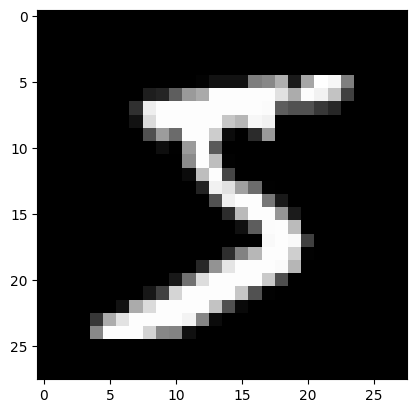

In [8]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("x_train shape:", x_train.shape)
print("Etiqueta 0 conjunto de train:", y_train[0])
plt.imshow(x_train[0], cmap='gray')

In [11]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [14]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9086 - loss: 0.3297 - val_accuracy: 0.9507 - val_loss: 0.1737
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9548 - loss: 0.1544 - val_accuracy: 0.9611 - val_loss: 0.1331
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9686 - loss: 0.1077 - val_accuracy: 0.9663 - val_loss: 0.1123
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9771 - loss: 0.0812 - val_accuracy: 0.9703 - val_loss: 0.1012
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9812 - loss: 0.0643 - val_accuracy: 0.9720 - val_loss: 0.0894


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[2.3199307e-06 3.5340488e-08 5.0542480e-05 4.2058569e-03 2.5365172e-09
  1.7679356e-06 4.9567656e-10 9.9569958e-01 7.7980203e-06 3.2008433e-05]]


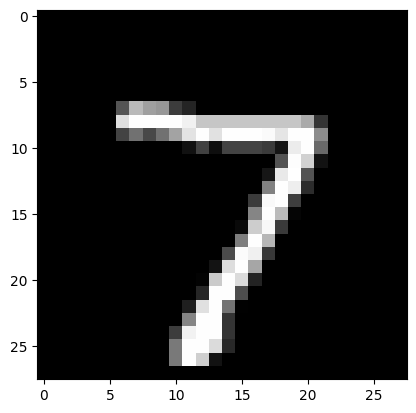

In [18]:
pred = model.predict(x_test[0:1])
print(pred)
plt.imshow(x_test[0], cmap='gray')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0824
NUESTRO RESULTADO FINAL
Test loss: 0.08240088820457458
Test Acc: 0.9751999974250793


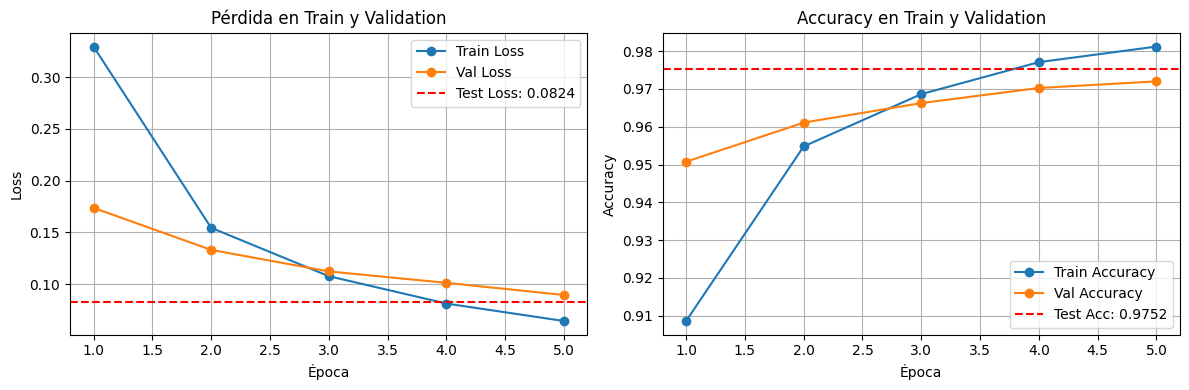

In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("NUESTRO RESULTADO FINAL")

print("Test loss:", test_loss)
print("Test Acc:", test_acc)

draw_plot(history.history["loss"], history.history["accuracy"], history.history["val_loss"], history.history["val_accuracy"], test_loss, test_acc)